In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 로드
file_path = '../data/hotel_bookings.csv'
df = pd.read_csv(file_path)
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# 데이터 기본 정보 확인
print('Shape:', df.shape)
df.info()
df.describe()

Shape: (119390, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


,missing_count,missing_percent
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


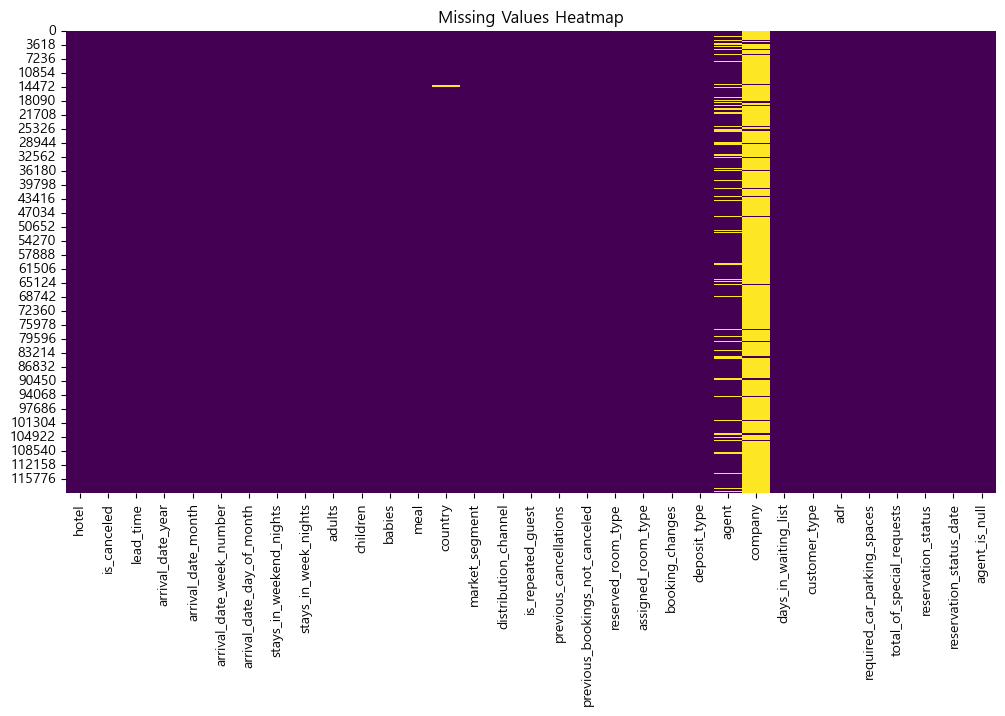

In [15]:
# 결측치가 있는 피처와 결측치 수/비율 확인
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if missing.empty:
    print("결측치가 있는 피처가 없습니다.")
else:
    missing_percent = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'missing_count': missing, 'missing_percent': missing_percent})
    display(missing_df)
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

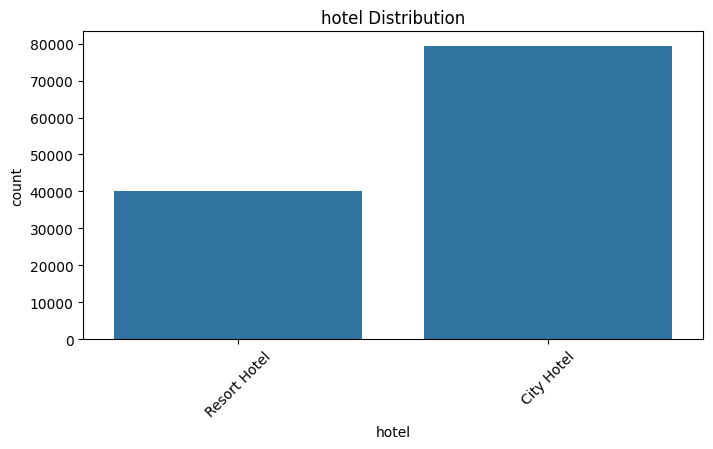

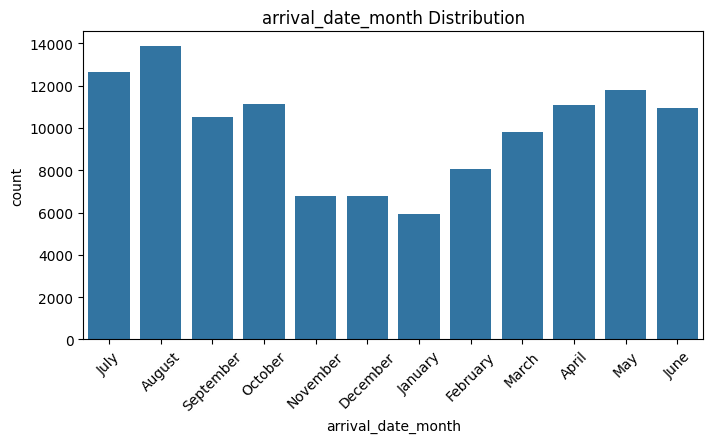

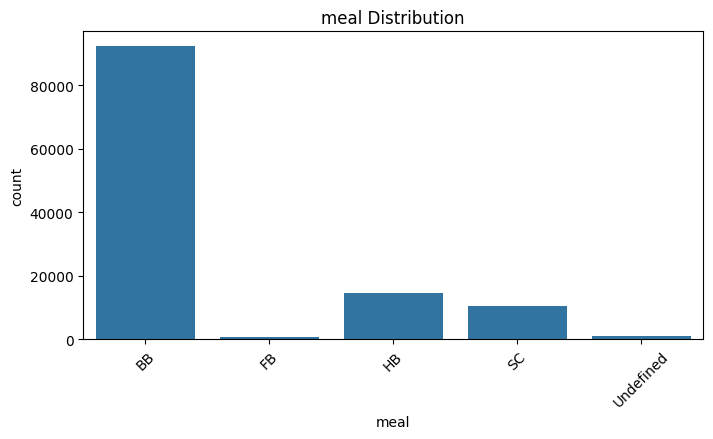

In [6]:
# 주요 범주형 변수 분포 시각화
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols[:3]:  # 상위 3개만 예시로 시각화
    plt.figure(figsize=(8,4))
    sns.countplot(data=df, x=col)
    plt.title(f'{col} Distribution')
    plt.xticks(rotation=45)
    plt.show()

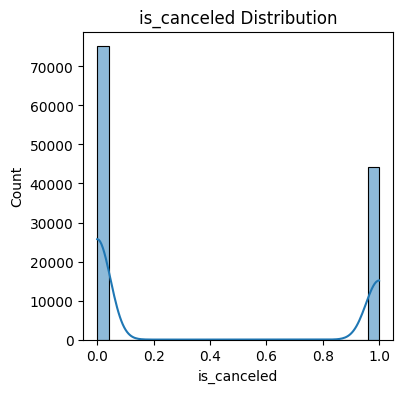

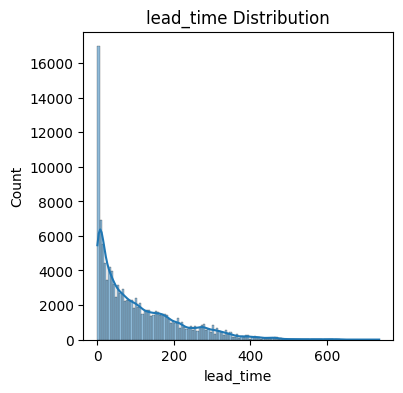

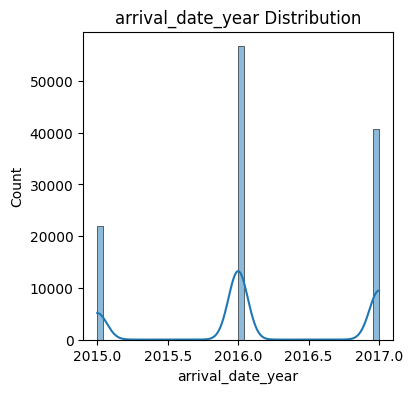

In [10]:
# 주요 수치형 변수 분포 시각화
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numeric_cols[:3]:  # 상위 3개만 예시로 시각화
    plt.figure(figsize=(4,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')
    plt.show()

agent 결측치 여부별 취소율:
agent_is_null
0    0.390044
1    0.246634
Name: is_canceled, dtype: float64


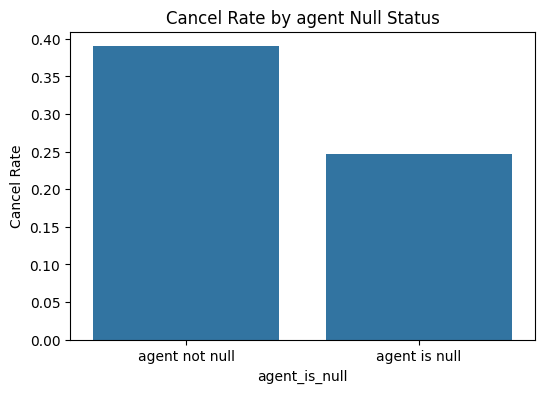

In [11]:
# agent 결측치와 is_canceled(target) 간의 관계 분석
# agent 결측치 여부 컬럼 생성
df['agent_is_null'] = df['agent'].isnull().astype(int)

# 결측치 여부별 취소율 비교
cancel_rate = df.groupby('agent_is_null')['is_canceled'].mean()
print('agent 결측치 여부별 취소율:')
print(cancel_rate)

# 시각화
plt.figure(figsize=(6,4))
sns.barplot(x=cancel_rate.index, y=cancel_rate.values)
plt.xticks([0,1], ['agent not null', 'agent is null'])
plt.ylabel('Cancel Rate')
plt.title('Cancel Rate by agent Null Status')
plt.show()

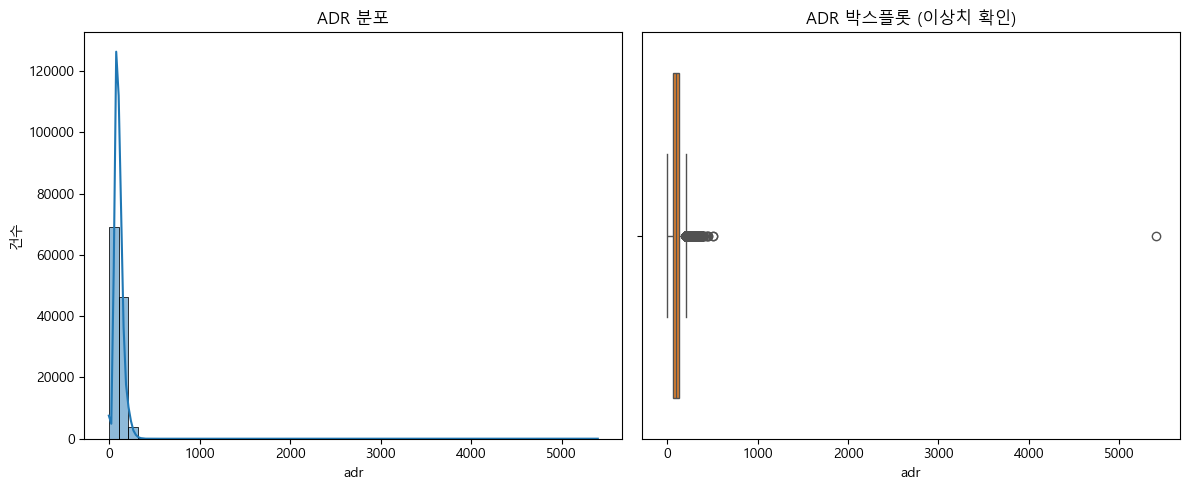

In [14]:
plt.rcParams['font.family'] = "Malgun Gothic"

plt.figure(figsize=(12,5))

# 히스토그램 + KDE
plt.subplot(1,2,1)
sns.histplot(df['adr'], kde=True, bins=50, color='C0')
plt.title('ADR 분포')
plt.xlabel('adr')
plt.ylabel('건수')

# 박스플롯으로 이상치 확인
plt.subplot(1,2,2)
sns.boxplot(x=df['adr'], color='C1')
plt.title('ADR 박스플롯 (이상치 확인)')
plt.xlabel('adr')

plt.tight_layout()
plt.show()